In [1]:
# Team 5 — SVM-Based Line Following
# Task 1 — Preparation

import os
from pathlib import Path
import glob

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_curve,
    auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

class_names = np.array(["LEFT", "STRAIGHT", "RIGHT"])

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Labels and Classes
### Synthetic Data (Lab07)
- 0 = LEFT      -> line appears left at the bottom
- 1 = STRAIGHT  -> line appears centered at the bottom
- 2 = RIGHT     -> line appears right at the bottom

### CARLA Data (Lab07b)
- -1 = LEFT     -> line leans left
-  0 = STRAIGHT -> line near vertical
-  1 = RIGHT    -> line leans right

### Science Truck Data & Combined Model
- -1 = LEFT     -> line appears left of center
-  0 = STRAIGHT -> line appears centered
-  1 = RIGHT    -> line appears right of center

### Note
Synthetic labels remapped from (0,1,2) to (-1,0,1) to match
truck and combined model scheme.

## Dataset Documentation

### Synthetic Dataset (Lab07)
- **Source:** Generated using `generate_dataset()` from Lab07
- **Samples:** 1200 images
- **Image size:** 64×64 pixels
- **Classes:** LEFT (0), STRAIGHT (1), RIGHT (2)
- **Class distribution:** roughly balanced (~32% each)
- **Features:** minimal features (bottom offset, brightness per region) and extended features (line direction, curvature, brightness balance)
- **Noise:** Gaussian noise added to simulate real camera conditions
- **Curvature:** enabled to simulate real road curves

### CARLA Dataset (Lab07b)
- **Source:** Kaggle — Lane Detection for CARLA Driving Simulator
- **Images processed:** 500
- **Patches extracted:** 948
- **Classes:** LEFT (-1), RIGHT (1)
- **Feature representation:** 64×64 edge patches flattened to 4096 features
- **Label method:** angle-based orientation from Hough line segments

### Science Truck Dataset
- **Source:**data from HSHL Science Truck bag file
- **Frames extracted:** 37,643
- **Feature:** Green line offset from image center (from line_detection_example.py)
- **Classes:** LEFT (-1), STRAIGHT (0), RIGHT (1)
- **Status:** Integrated

### Combined Dataset (Final Model)
- **Source:** Synthetic + Science Truck data
- **Total samples:** 38,843
- **Feature:** bottom_offset (Lab07 extended features)
- **Note:** CARLA data evaluated separately due to incompatible
  edge patch features


In [14]:
# Section 2 — Synthetic Data Generation
# (Lab07 Section 2)

def generate_line_image(
    img_size=64,
    command=1,
    curvature=0.0,
    thickness=3,
    noise_level=0.06,
    brightness=1.0,
    random_state=None
):
    """
    Generate one synthetic black-background image with a white line.

    command:
        0 = LEFT      -> line appears left at the bottom
        1 = STRAIGHT  -> line appears centered at the bottom
        2 = RIGHT     -> line appears right at the bottom
    """
    rng = np.random.default_rng(random_state)
    img = np.zeros((img_size, img_size), dtype=float)

    base_center = img_size // 2

    if command == 0:
        bottom_x = base_center - rng.integers(8, 18)
    elif command == 2:
        bottom_x = base_center + rng.integers(8, 18)
    else:
        bottom_x = base_center + rng.integers(-5, 6)

    slope = rng.normal(0.0, 0.10)

    ys = np.arange(img_size)
    y_norm = (img_size - 1 - ys) / (img_size - 1)

    xs = (
        bottom_x
        + slope * (ys - img_size / 2)
        + curvature * (y_norm ** 2) * img_size
    )

    for y_pos, x_pos in zip(ys, xs):
        x_int = int(round(x_pos))
        for dx in range(-thickness, thickness + 1):
            xx = x_int + dx
            if 0 <= xx < img_size:
                img[y_pos, xx] = brightness

    # Slight softening of the line
    img_shift_left = np.roll(img, 1, axis=1) * 0.35
    img_shift_right = np.roll(img, -1, axis=1) * 0.35
    img = np.clip(img + img_shift_left + img_shift_right, 0, 1)

    # Sensor noise
    img += rng.normal(0, noise_level, img.shape)
    img = np.clip(img, 0, 1)

    return img


def generate_dataset(
    n_samples=1200,
    img_size=64,
    noise_level=0.06,
    curved=True,
    random_state=42
):
    """
    Generate a dataset of synthetic line-following images.

    If curved=False, the data is simpler and mostly straight.
    If curved=True, line curvature is added.
    """
    rng = np.random.default_rng(random_state)
    images = []
    labels = []

    class_probs = [0.32, 0.36, 0.32]

    for _ in range(n_samples):
        command = rng.choice([0, 1, 2], p=class_probs)

        if curved:
            curvature = rng.normal(0.0, 0.10)
            if command == 0:
                curvature += rng.normal(-0.06, 0.04)
            elif command == 2:
                curvature += rng.normal(0.06, 0.04)
        else:
            curvature = rng.normal(0.0, 0.015)

        thickness = rng.integers(2, 5)
        brightness = rng.uniform(0.75, 1.0)

        img = generate_line_image(
            img_size=img_size,
            command=command,
            curvature=curvature,
            thickness=thickness,
            noise_level=noise_level,
            brightness=brightness,
            random_state=rng.integers(0, 1_000_000)
        )

        images.append(img)
        labels.append(command)

    return np.array(images), np.array(labels)

# Feature Extraction — Minimal and Extended

def extract_minimal_features(images):
    """
    Minimal baseline feature extraction.

    Only one idea is used:
    Where is the line at the bottom of the image?

    Features:
    - bottom_offset: normalized x-position of the white line in the lower image region
    - bottom_left_brightness
    - bottom_center_brightness
    - bottom_right_brightness

    This is intentionally simple.
    """
    rows = []
    eps = 1e-8

    for img in images:
        h, w = img.shape
        bottom = img[int(0.70*h):, :]

        third = w // 3
        left_region = bottom[:, :third]
        center_region = bottom[:, third:2*third]
        right_region = bottom[:, 2*third:]

        _, xx = np.mgrid[0:bottom.shape[0], 0:w]
        cx_bottom = (bottom * xx).sum() / (bottom.sum() + eps)
        bottom_offset = (cx_bottom - w/2) / (w/2)

        rows.append({
            "bottom_offset": bottom_offset,
            "bottom_left_brightness": left_region.mean(),
            "bottom_center_brightness": center_region.mean(),
            "bottom_right_brightness": right_region.mean(),
        })

    return pd.DataFrame(rows)


def extract_extended_features(images):
    """
    Extended feature extraction.

    This mimics a simple perception pipeline using multiple interpretable features:
    - center of line in lower image half
    - center of line in upper image half
    - bottom, middle, and top offsets
    - line direction
    - curvature proxy
    - brightness and left/right balance
    """
    feature_rows = []
    eps = 1e-8

    for img in images:
        h, w = img.shape
        yy, xx = np.mgrid[0:h, 0:w]

        total = img.sum() + eps

        cx = (img * xx).sum() / total
        cy = (img * yy).sum() / total

        lower = img[h//2:, :]
        upper = img[:h//2, :]

        yy_l, xx_l = np.mgrid[h//2:h, 0:w]
        yy_u, xx_u = np.mgrid[0:h//2, 0:w]

        lower_total = lower.sum() + eps
        upper_total = upper.sum() + eps

        cx_lower = (lower * xx_l).sum() / lower_total
        cx_upper = (upper * xx_u).sum() / upper_total

        bottom_region = img[int(0.75*h):, :]
        middle_region = img[int(0.45*h):int(0.65*h), :]
        top_region = img[:int(0.25*h), :]

        def region_cx(region):
            if region.sum() < eps:
                return w / 2
            _, region_xx = np.mgrid[0:region.shape[0], 0:region.shape[1]]
            return (region * region_xx).sum() / (region.sum() + eps)

        cx_bottom = region_cx(bottom_region)
        cx_middle = region_cx(middle_region)
        cx_top = region_cx(top_region)

        bottom_offset = (cx_bottom - w/2) / (w/2)
        middle_offset = (cx_middle - w/2) / (w/2)
        top_offset = (cx_top - w/2) / (w/2)

        line_direction = (cx_lower - cx_upper) / h

        expected_middle = 0.5 * (cx_bottom + cx_top)
        curvature_proxy = (cx_middle - expected_middle) / (w/2)

        white_ratio = (img > 0.5).mean()
        mean_brightness = img.mean()

        left_half = img[:, :w//2].sum()
        right_half = img[:, w//2:].sum()
        left_right_balance = (right_half - left_half) / (right_half + left_half + eps)

        lower_brightness = lower.mean()
        upper_brightness = upper.mean()

        feature_rows.append({
            "cx_global": (cx - w/2) / (w/2),
            "cy_global": cy / h,
            "cx_lower": (cx_lower - w/2) / (w/2),
            "cx_upper": (cx_upper - w/2) / (w/2),
            "bottom_offset": bottom_offset,
            "middle_offset": middle_offset,
            "top_offset": top_offset,
            "line_direction": line_direction,
            "curvature_proxy": curvature_proxy,
            "white_ratio": white_ratio,
            "mean_brightness": mean_brightness,
            "left_right_balance": left_right_balance,
            "lower_brightness": lower_brightness,
            "upper_brightness": upper_brightness,
        })

    return pd.DataFrame(feature_rows)

images shape: (1200, 64, 64)
y shape: (1200,)
Class distribution: {np.int64(0): np.int64(399), np.int64(1): np.int64(434), np.int64(2): np.int64(367)}


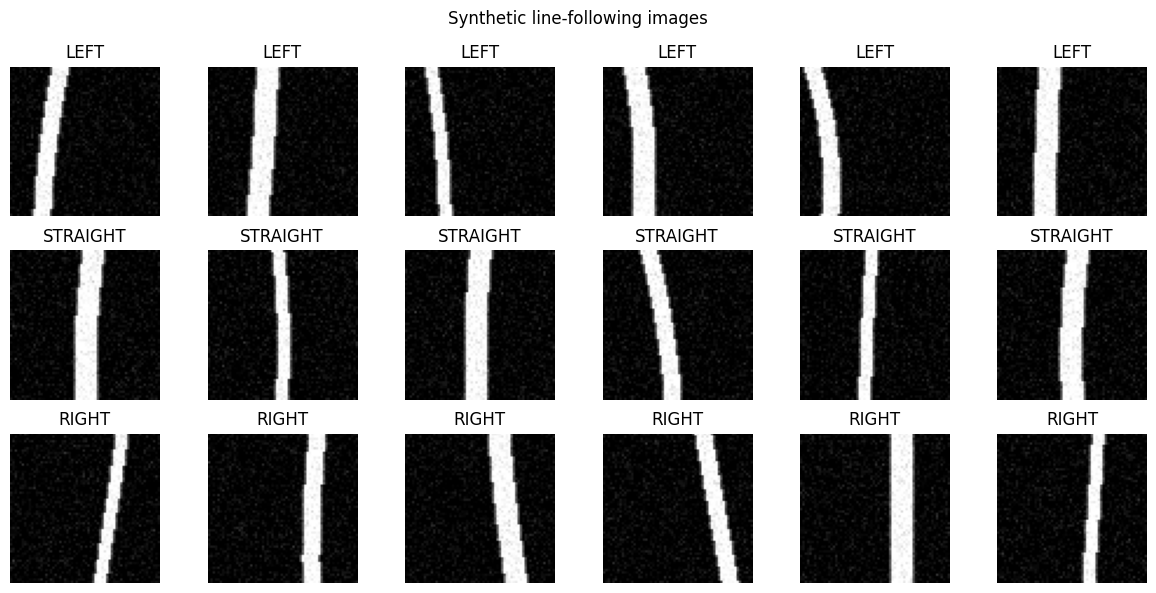

In [15]:
images, y = generate_dataset(
    n_samples=1200, 
    curved=True, 
    random_state=RANDOM_STATE
)

print("images shape:", images.shape)
print("y shape:", y.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for row, cls_idx in enumerate([0, 1, 2]):
    sample_indices = np.where(y == cls_idx)[0][:6]
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(images[idx], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        axes[row, col].set_title(class_names[cls_idx])
plt.suptitle("Synthetic line-following images")
plt.tight_layout()
plt.show()

In [16]:
X_extended = extract_extended_features(images)

print("Extended features:")
display(X_extended.head())

Extended features:


,cx_global,cy_global,cx_lower,cx_upper,bottom_offset,middle_offset,top_offset,line_direction,curvature_proxy,white_ratio,mean_brightness,left_right_balance,lower_brightness,upper_brightness
0,0.255282,0.493807,0.196452,0.314562,0.165304,0.248072,0.344507,-0.059055,-0.006834,0.078125,0.106347,0.769482,0.106754,0.105941
1,0.317234,0.493688,0.302280,0.332358,0.306419,0.304867,0.345359,-0.015039,-0.021022,0.109375,0.137217,0.827275,0.137995,0.136439
2,0.018312,0.492801,0.002718,0.033873,0.010190,-0.005575,0.052585,-0.015578,-0.036963,0.140625,0.167480,0.226167,0.167295,0.167664
3,-0.019374,0.490211,-0.013675,-0.024995,-0.017936,0.006702,-0.035769,0.005660,0.033555,0.078125,0.107010,-0.067538,0.106264,0.107757
4,0.292664,0.492318,0.342688,0.242493,0.369736,0.300196,0.217344,0.050098,0.006655,0.140869,0.166656,0.858863,0.166900,0.166412


In [17]:
X_train_min, X_test_min, y_train, y_test = train_test_split(
    X_extended, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train_min))
print("Test samples:", len(X_test_min))

Training samples: 900
Test samples: 300


In [18]:
X_synthetic_offset = X_extended[["bottom_offset"]].values

label_map = {0: -1, 1: 0, 2: 1}
y_synthetic_remapped = np.array([label_map[label] for label in y])

print("Synthetic offset shape:", X_synthetic_offset.shape)
print("Remapped labels:", np.unique(y_synthetic_remapped, return_counts=True))

Synthetic offset shape: (1200, 1)
Remapped labels: (array([-1,  0,  1]), array([399, 434, 367]))


In [19]:
svm_initial = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE))
])

svm_initial.fit(X_train_min, y_train)
y_pred_initial = svm_initial.predict(X_test_min)

print("--- Initial SVM (Synthetic Data) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_initial))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_initial))

--- Initial SVM (Synthetic Data) ---
Accuracy: 0.9866666666666667
Confusion matrix:
[[ 99   1   0]
 [  0 107   1]
 [  0   2  90]]


In [22]:
try:
    import kagglehub
    print("kagglehub already available.")
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install kagglehub
    import kagglehub

dataset_path = kagglehub.dataset_download(
    "thomasfermi/lane-detection-for-carla-driving-simulator"
)
print("Dataset downloaded to:", dataset_path)

kagglehub already available.
Dataset downloaded to: C:\Users\victo\.cache\kagglehub\datasets\thomasfermi\lane-detection-for-carla-driving-simulator\versions\1


In [23]:
from pathlib import Path

dataset_path = Path(dataset_path)

image_files = []
for extension in ["*.png", "*.jpg", "*.jpeg"]:
    image_files.extend(dataset_path.rglob(extension))

def looks_like_camera_image(path):
    name = path.name.lower()
    excluded_keywords = ["mask", "label", "seg", "annotation", "gt"]
    return not any(keyword in name for keyword in excluded_keywords)

image_files = sorted([p for p in image_files if looks_like_camera_image(p)])
print("Images found:", len(image_files))

if len(image_files) > 0:
    print("Example image path:")
    print(image_files[0])
else:
    print("No image files found. Check dataset_path.")

Images found: 3204
Example image path:
C:\Users\victo\.cache\kagglehub\datasets\thomasfermi\lane-detection-for-carla-driving-simulator\versions\1\train\Town04_Clear_Noon_09_09_2020_14_57_22_frame_0.png


In [8]:
sample_image_path = image_files[0]

image_bgr = cv2.imread(str(sample_image_path))

if image_bgr is None:
    raise ValueError("Image could not be loaded. Check the file path.")

print("Image shape:", image_bgr.shape)
print("Data type:", image_bgr.dtype)
print("Minimum pixel value:", image_bgr.min())
print("Maximum pixel value:", image_bgr.max())

Image shape: (512, 1024, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 245


In [9]:
#Resize, Grayscale, ROI
#Lab07b Section 6-8
def preprocess_for_line_candidates(
    image_path,
    target_size=(320, 180),
    roi_start_fraction=0.45
):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    image = cv2.resize(image, target_size)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    height, width = gray.shape
    y_start = int(height * roi_start_fraction)
    roi = gray[y_start:, :]

    return image, gray, roi, y_start



# Edge 
# (Lab07b Section 11)

def compute_edges(
    roi,
    blur_kernel=(5, 5),
    canny_low=50,
    canny_high=150
):
    blurred = cv2.GaussianBlur(roi, blur_kernel, 0)
    edges = cv2.Canny(blurred, canny_low, canny_high)
    return edges


# Line Detection
# (Lab07b Section 14)
def detect_line_segments(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=25,
    min_line_length=25,
    max_line_gap=15
):
    lines = cv2.HoughLinesP(
        edges,
        rho=rho,
        theta=theta,
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    if lines is None:
        return []

    return [line[0] for line in lines]


# Segment Geometry
# (Lab07b Section 15)
def segment_geometry(segment):
    x1, y1, x2, y2 = segment

    dx = x2 - x1
    dy_img = y2 - y1
    dy_cart = -dy_img

    length = float(np.sqrt(dx**2 + dy_img**2))
    angle_deg = float(np.degrees(np.arctan2(dy_cart, dx)))

    x_center = (x1 + x2) / 2.0
    y_center = (y1 + y2) / 2.0

    return {
        "x1": int(x1),
        "y1": int(y1),
        "x2": int(x2),
        "y2": int(y2),
        "dx": float(dx),
        "dy_img": float(dy_img),
        "dy_cart": float(dy_cart),
        "length": length,
        "angle_deg": angle_deg,
        "x_center": float(x_center),
        "y_center": float(y_center)
    }


# Orientation Label from Angle
# (Lab07b Section 15)
def orientation_label_from_angle(angle_deg, diagonal_threshold=20, vertical_threshold=70):
    if abs(angle_deg) >= vertical_threshold:
        return 0

    if angle_deg > diagonal_threshold:
        return 1

    if angle_deg < -diagonal_threshold:
        return -1

    return None


# Filter Clear Line Candidates
# (Lab07b Section 16)
def extract_clear_line_candidates(
    segments,
    roi_shape,
    min_length=35,
    diagonal_threshold=20,
    vertical_threshold=70
):
    candidates = []

    for segment in segments:
        g = segment_geometry(segment)

        if g["length"] < min_length:
            continue

        label = orientation_label_from_angle(
            g["angle_deg"],
            diagonal_threshold=diagonal_threshold,
            vertical_threshold=vertical_threshold
        )

        if label is None:
            continue

        g["label"] = label
        candidates.append(g)

    return pd.DataFrame(candidates)


# Crop Patch Around Segment
# (Lab07b Section 17)
def crop_patch_around_segment(
    image_2d,
    row,
    patch_size=(64, 64)
):
    patch_w, patch_h = patch_size

    x_center = int(row["x_center"])
    y_center = int(row["y_center"])

    x1 = max(0, x_center - patch_w // 2)
    x2 = min(image_2d.shape[1], x_center + patch_w // 2)

    y1 = max(0, y_center - patch_h // 2)
    y2 = min(image_2d.shape[0], y_center + patch_h // 2)

    patch = image_2d[y1:y2, x1:x2]

    patch = cv2.resize(patch, patch_size)

    return patch


# Full Pipeline Per Image — Extract Edge Patches
# (Lab07b Section 18)
def extract_patches_from_image(
    image_path,
    target_size=(320, 180),
    roi_start_fraction=0.45,
    patch_size=(64, 64),
    min_edge_pixels_in_patch=20
):
    image, gray, roi, y_start = preprocess_for_line_candidates(
        image_path,
        target_size=target_size,
        roi_start_fraction=roi_start_fraction
    )

    edges = compute_edges(roi)
    segments = detect_line_segments(edges)
    candidates_df = extract_clear_line_candidates(segments, roi.shape)

    patches = []
    labels = []
    metadata = []

    for _, row in candidates_df.iterrows():
        edge_patch = crop_patch_around_segment(edges, row, patch_size=patch_size)

        number_of_edge_pixels = int(np.count_nonzero(edge_patch))

        if number_of_edge_pixels < min_edge_pixels_in_patch:
            continue

        patches.append(edge_patch)
        labels.append(int(row["label"]))

        meta = row.to_dict()
        meta["filename"] = str(image_path)
        meta["edge_pixels_in_patch"] = number_of_edge_pixels
        metadata.append(meta)

    return patches, labels, metadata


print("All functions defined.")

All functions defined.


In [10]:
max_images = min(500, len(image_files))

patches = []
labels = []
metadata = []

for path in image_files[:max_images]:
    p, l, m = extract_patches_from_image(path)
    patches.extend(p)
    labels.extend(l)
    metadata.extend(m)

labels = np.array(labels)
metadata_df = pd.DataFrame(metadata)

print("Processed images:", max_images)
print("Extracted patches:", len(patches))
print("Available labels:", np.unique(labels) if len(labels) > 0 else "none")

Processed images: 500
Extracted patches: 948
Available labels: [-1  1]


Patch non-zero pixel statistics:
Minimum: 61
Mean: 258.292194092827
Maximum: 941


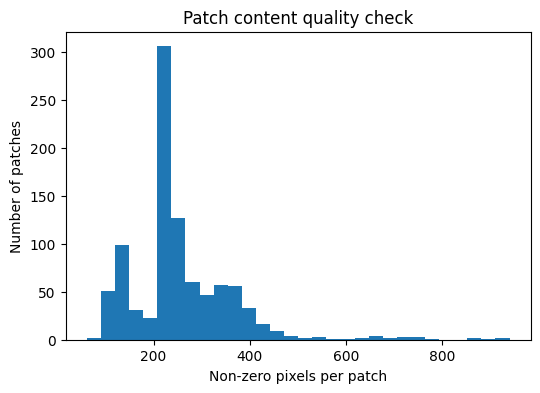

In [11]:
if len(patches) > 0:
    nonzero_counts = np.array([np.count_nonzero(patch) for patch in patches])

    print("Patch non-zero pixel statistics:")
    print("Minimum:", nonzero_counts.min())
    print("Mean:", nonzero_counts.mean())
    print("Maximum:", nonzero_counts.max())

    plt.figure(figsize=(6, 4))
    plt.hist(nonzero_counts, bins=30)
    plt.xlabel("Non-zero pixels per patch")
    plt.ylabel("Number of patches")
    plt.title("Patch content quality check")
    plt.show()
else:
    print("No patches available for quality check.")

,label,count
0,-1,645
1,1,303


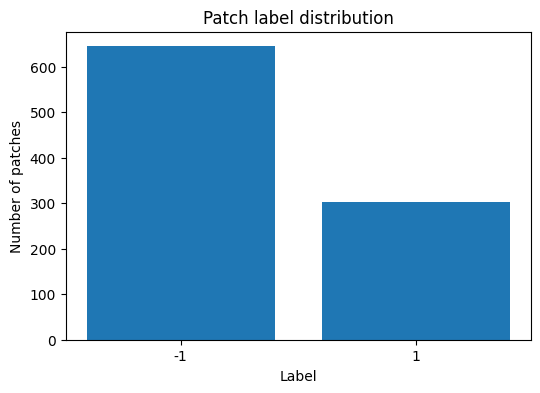

In [12]:
if len(labels) > 0:
    unique, counts = np.unique(labels, return_counts=True)

    distribution_df = pd.DataFrame({
        "label": unique,
        "count": counts
    })

    display(distribution_df)

    plt.figure(figsize=(6, 4))
    plt.bar(unique.astype(str), counts)
    plt.xlabel("Label")
    plt.ylabel("Number of patches")
    plt.title("Patch label distribution")
    plt.show()
else:
    print("No patches extracted.")

In [13]:
X = []
y_filtered = []
valid_patches = []

for patch, label in zip(patches, labels):
    if np.count_nonzero(patch) == 0:
        continue

    patch_norm = patch.astype(np.float32) / 255.0
    X.append(patch_norm.flatten())
    y_filtered.append(label)
    valid_patches.append(patch)

X = np.array(X)
y = np.array(y_filtered)
valid_patches = np.array(valid_patches)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Valid patch array shape:", valid_patches.shape)
print("Classes:", np.unique(y) if len(y) > 0 else "none")

X shape: (948, 4096)
y shape: (948,)
Valid patch array shape: (948, 64, 64)
Classes: [-1  1]


In [14]:
#save metadata
metadata_output_file = "solid_line_patch_metadata.csv"

if len(metadata_df) > 0:
    metadata_df.to_csv(metadata_output_file, index=False)
    print("Saved metadata:", metadata_output_file)
else:
    print("No metadata to save.")

Saved metadata: solid_line_patch_metadata.csv


Class counts:


-1    645
 1    303
Name: count, dtype: int64

Training samples: 711
Test samples: 237


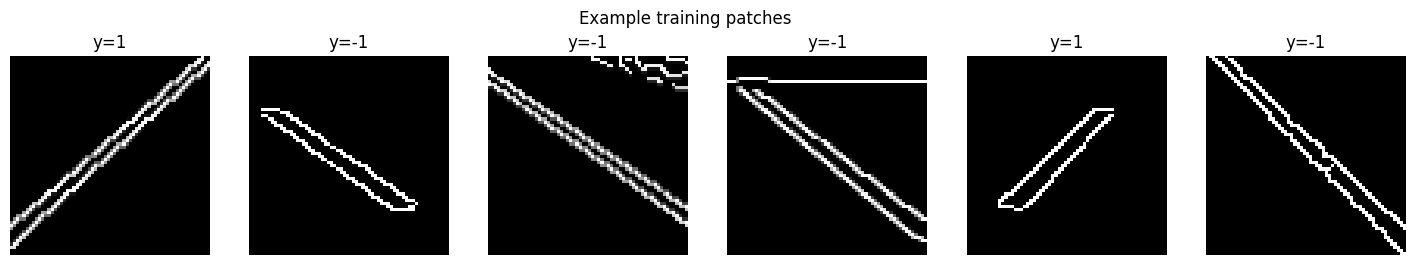

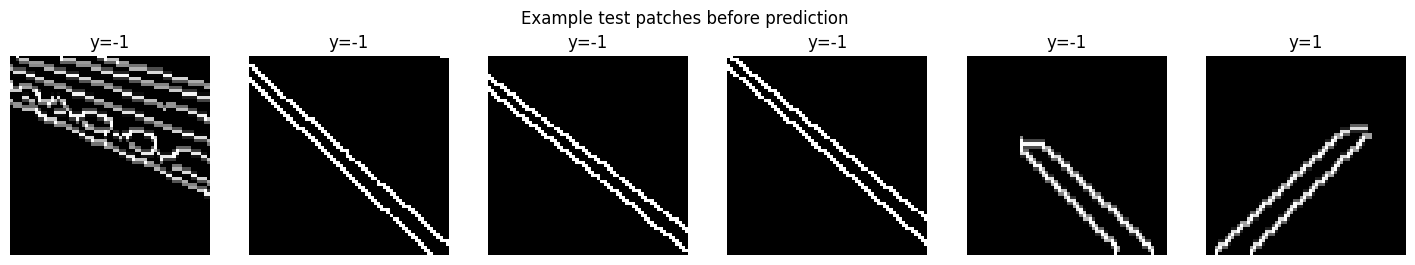

Accuracy: 0.9704641350210971
Confusion matrix:
[[161   0]
 [  7  69]]


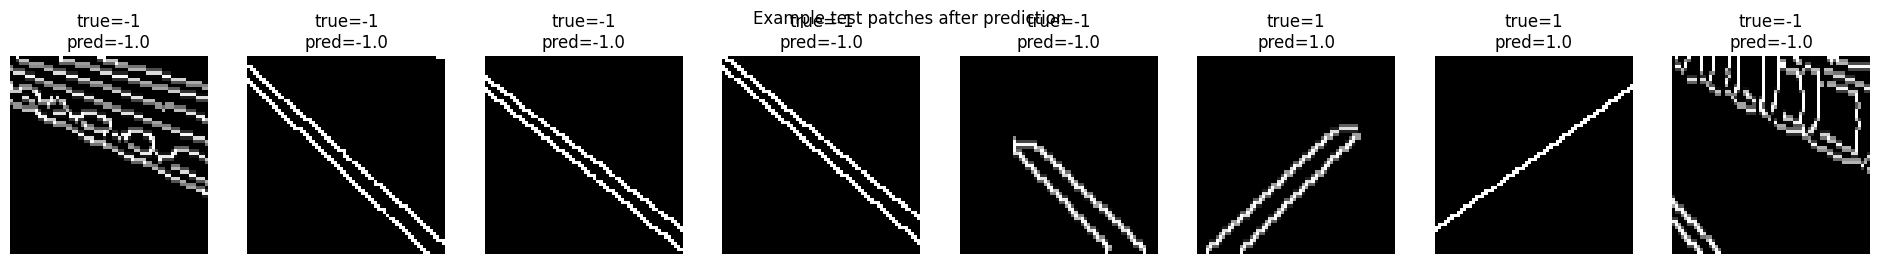

In [15]:
def show_patch_grid(patches_array, labels_array, indices, title, predictions=None, max_examples=8):
    n = min(max_examples, len(indices))
    if n == 0:
        print("No examples to show.")
        return
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices[:n]):
        ax.imshow(patches_array[idx], cmap="gray")
        if predictions is None:
            ax.set_title(f"y={labels_array[idx]}")
        else:
            ax.set_title(f"true={labels_array[idx]}\npred={predictions[idx]}")
        ax.axis("off")
    plt.suptitle(title)
    plt.show()

if len(y) == 0:
    print("Training skipped: no valid samples available.")
elif len(np.unique(y)) < 2:
    print("Training skipped: fewer than two classes available.")
else:
    class_counts = pd.Series(y).value_counts()
    print("Class counts:")
    display(class_counts.sort_index())
    if class_counts.min() < 2:
        print("Training skipped: at least one class has fewer than two samples.")
    else:
        indices = np.arange(len(y))
        train_idx, test_idx = train_test_split(
            indices,
            test_size=0.25,
            random_state=42,
            stratify=y
        )
        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        print("Training samples:", len(train_idx))
        print("Test samples:", len(test_idx))
        show_patch_grid(
            valid_patches,
            y,
            train_idx,
            "Example training patches",
            max_examples=6
        )
        show_patch_grid(
            valid_patches,
            y,
            test_idx,
            "Example test patches before prediction",
            max_examples=6
        )
        svm_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
        ])
        svm_pipeline.fit(X_train, y_train)
        y_pred = svm_pipeline.predict(X_test)
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))
        all_predictions = np.full(shape=len(y), fill_value=np.nan)
        all_predictions[test_idx] = y_pred
        show_patch_grid(
            valid_patches,
            y,
            test_idx,
            "Example test patches after prediction",
            predictions=all_predictions,
            max_examples=8
        )

In [23]:
svm_linear_carla = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE))
])
svm_linear_carla.fit(X_train, y_train)
y_pred_linear_carla = svm_linear_carla.predict(X_test)

print("--- Linear SVM (CARLA Data) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_linear_carla))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_linear_carla))

--- Linear SVM (CARLA Data) ---
Accuracy: 1.0
Confusion matrix:
[[161   0]
 [  0  76]]


In [24]:
param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid_search_carla = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(random_state=RANDOM_STATE))
    ]),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search_carla.fit(X_train, y_train)

print("Best parameters:", grid_search_carla.best_params_)
print("Best CV accuracy:", grid_search_carla.best_score_)
print("Test accuracy:", accuracy_score(y_test, grid_search_carla.predict(X_test)))

Best parameters: {'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV accuracy: 0.9985915492957746
Test accuracy: 1.0


In [25]:
joblib.dump(grid_search_carla.best_estimator_, "team5_svm_carla.pkl")
print("CARLA model saved as team5_svm_carla.pkl")
print("Best parameters:", grid_search_carla.best_params_)

CARLA model saved as team5_svm_carla.pkl
Best parameters: {'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


## Note on Dataset Combination
CARLA data uses edge patch features (4096 dimensions) from Lab07b,
which are incompatible with the offset features used in the synthetic
and truck datasets. CARLA results are evaluated separately. The final
combined model uses synthetic and truck data which share the same
bottom_offset feature representation from Lab07.

In [24]:
truck_frames_path = Path(r"X:\victo\Documents\Machine-Learning\visualization_output\frames")
truck_image_files = sorted(truck_frames_path.glob("*.jpg"))

print("Truck frames found:", len(truck_image_files))

Truck frames found: 37643


In [25]:
# Science Truck Data - Feature Extraction
# (from line_detection_example.py

def extract_truck_features(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        return None, None

    # Convert to HSV (more robust to lighting)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Green in HSV
    lower_green = np.array([40, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Clean up noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Find contours
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours or cv2.contourArea(max(contours, key=cv2.contourArea)) < 100:
        return None, None

    largest_contour = max(contours, key=cv2.contourArea)

    # Fit line to contour
    rows, cols = mask.shape[:2]
    [vx, vy, x, y] = cv2.fitLine(largest_contour, cv2.DIST_L2, 0, 0.01, 0.01)

    center_row = rows // 2
    if abs(vy) > 0.01:
        line_x_at_center = x + (center_row - y) * (vx / vy)
    else:
        M = cv2.moments(largest_contour)
        line_x_at_center = M["m10"] / M["m00"] if M["m00"] > 0 else cols // 2

    # Calculate offset
    image_center_x = cols / 2.0
    offset = float(np.squeeze(line_x_at_center - image_center_x) / image_center_x)

    # Label based on offset
    if offset < -0.1:
        label = -1  # LEFT
    elif offset > 0.1:
        label = 1   # RIGHT
    else:
        label = 0   # STRAIGHT

    return offset, label

print("Truck feature extraction defined")

Truck feature extraction defined


In [26]:
#Science Truck Data - Build Dataset

truck_features = []
truck_labels = []

for path in truck_image_files:
    feature, label = extract_truck_features(path)
    if feature is None:
        continue
    truck_features.append([feature])
    truck_labels.append(label)

truck_features = np.array(truck_features)
truck_labels = np.array(truck_labels)

print("Truck samples:", len(truck_features))
print("Label distribution:", dict(zip(*np.unique(truck_labels, return_counts=True))))

Truck samples: 37643
Label distribution: {np.int64(-1): np.int64(14950), np.int64(0): np.int64(12553), np.int64(1): np.int64(10140)}


In [27]:
# Science Truck Data — Train/Test Split

X_train_truck, X_test_truck, y_train_truck, y_test_truck = train_test_split(
    truck_features, truck_labels,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=truck_labels
)

print("Truck training samples:", len(X_train_truck))
print("Truck test samples:", len(X_test_truck))

Truck training samples: 28232
Truck test samples: 9411


In [28]:
# Science Truck Data

# Linear SVM
svm_linear_truck = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE))
])
svm_linear_truck.fit(X_train_truck, y_train_truck)
y_pred_linear_truck = svm_linear_truck.predict(X_test_truck)

print("--- Linear SVM (Truck Data) ---")
print("Accuracy:", accuracy_score(y_test_truck, y_pred_linear_truck))
print("Confusion matrix:")
print(confusion_matrix(y_test_truck, y_pred_linear_truck))

# RBF SVM
svm_rbf_truck = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))
])
svm_rbf_truck.fit(X_train_truck, y_train_truck)
y_pred_rbf_truck = svm_rbf_truck.predict(X_test_truck)

print("\n--- RBF SVM (Truck Data) ---")
print("Accuracy:", accuracy_score(y_test_truck, y_pred_rbf_truck))
print("Confusion matrix:")
print(confusion_matrix(y_test_truck, y_pred_rbf_truck))

--- Linear SVM (Truck Data) ---
Accuracy: 0.9315694400170014
Confusion matrix:
[[3388  350    0]
 [   0 3138    0]
 [   0  294 2241]]

--- RBF SVM (Truck Data) ---
Accuracy: 0.9615343746679418
Confusion matrix:
[[3550  188    0]
 [   0 3138    0]
 [   0  174 2361]]


In [29]:
# Science Truck Data — Grid Search C and Gamma

param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid_search_truck = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(random_state=RANDOM_STATE))
    ]),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search_truck.fit(X_train_truck, y_train_truck)

print("Best parameters:", grid_search_truck.best_params_)
print("Best CV accuracy:", grid_search_truck.best_score_)
print("Test accuracy:", accuracy_score(y_test_truck, grid_search_truck.predict(X_test_truck)))

Best parameters: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV accuracy: 0.9975913091136264
Test accuracy: 0.9980873445967485


In [30]:
# Science Truck Data — Save Best Model
joblib.dump(grid_search_truck.best_estimator_, "team5_svm_truck.pkl")
print("Truck model saved as team5_svm_truck.pkl")
print("Best parameters:", grid_search_truck.best_params_)
print("Test accuracy:", accuracy_score(y_test_truck, grid_search_truck.predict(X_test_truck)))

Truck model saved as team5_svm_truck.pkl
Best parameters: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Test accuracy: 0.9980873445967485


In [31]:
# Refining SVM with real Science Truck data
# (Lab07 bottom_offset + truck offset)

X_combined = np.vstack([X_synthetic_offset, truck_features])
y_combined = np.concatenate([y_synthetic_remapped, truck_labels])

print("Combined dataset size:", len(X_combined))
print("Combined labels:", np.unique(y_combined, return_counts=True))

X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_combined
)

# Train final SVM on combined data
final_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=100, gamma="scale", random_state=RANDOM_STATE))
])

final_svm.fit(X_train_combined, y_train_combined)
y_pred_final = final_svm.predict(X_test_combined)

print("\n--- Final Combined SVM ---")
print("Accuracy:", accuracy_score(y_test_combined, y_pred_final))
print("Confusion matrix:")
print(confusion_matrix(y_test_combined, y_pred_final))

# Save final model
joblib.dump(final_svm, "team5_svm_final.pkl")
print("\nFinal model saved as team5_svm_final.pkl")

Combined dataset size: 38843
Combined labels: (array([-1,  0,  1]), array([15349, 12987, 10507]))

--- Final Combined SVM ---
Accuracy: 0.9922767995057151
Confusion matrix:
[[3807   30    0]
 [  15 3218   14]
 [   0   16 2611]]

Final model saved as team5_svm_final.pkl


Accuracy: 0.9922767995057151
F1-score: 0.9922978272563229

              precision    recall  f1-score   support

        LEFT       1.00      0.99      0.99      3837
    STRAIGHT       0.99      0.99      0.99      3247
       RIGHT       0.99      0.99      0.99      2627

    accuracy                           0.99      9711
   macro avg       0.99      0.99      0.99      9711
weighted avg       0.99      0.99      0.99      9711



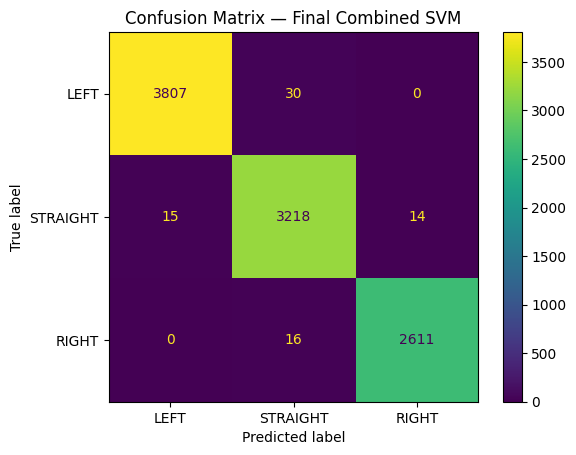

In [36]:
# Evaluation - Accuracy, Classification Report, Confusion Matrix
# (Lab06 Section 11)

print("Accuracy:", accuracy_score(y_test_combined, y_pred_final))
print("F1-score:", f1_score(y_test_combined, y_pred_final, average="macro"))
print()
print(classification_report(y_test_combined, y_pred_final, 
      target_names=["LEFT", "STRAIGHT", "RIGHT"]))

ConfusionMatrixDisplay.from_predictions(
    y_test_combined, 
    y_pred_final, 
    display_labels=["LEFT", "STRAIGHT", "RIGHT"]
)
plt.title("Confusion Matrix — Final Combined SVM")
plt.show()

In [38]:
def evaluate_under_noise(model, X_test, y_test, noise_std_values):
    results = []
    rng = np.random.default_rng(RANDOM_STATE)
    for noise_std in noise_std_values:
        noise = rng.normal(0, noise_std, X_test.shape)
        X_noisy = X_test.copy() + noise
        y_pred_noisy = model.predict(X_noisy)
        results.append({
            "noise_std": noise_std,
            "accuracy": accuracy_score(y_test, y_pred_noisy),
            "f1": f1_score(y_test, y_pred_noisy, average="macro", zero_division=0),
        })
    return pd.DataFrame(results)

noise_results = evaluate_under_noise(final_svm, X_test_combined, y_test_combined, [0, 0.5, 1.0, 2.0, 3.0])
noise_results

,noise_std,accuracy,f1
0,0.0,0.992277,0.992298
1,0.5,0.607455,0.551620
2,1.0,0.504376,0.439913
3,2.0,0.438266,0.371239
4,3.0,0.413552,0.342695


## Critical Scenarios

These are situations where the model might struggle or fail:m

### Bad lighting
The green line detection works by looking for green pixels. If the lighting changes — for example strong sunlight, shadows, or dim light — the green color might not look green to the camera anymore, and the model won't detect the line.

### Line not in frame
If the robot drives too far off track and the green line is no longer visible in the camera image, the model returns None and the robot just goes straight. This could make things worse.

### Noise sensitivity
Our robustness test showed that accuracy drops from 99% to 60% when even a small amount of noise is added. This is because the model only uses one number (the offset) to make decisions — if that number is slightly off, the whole prediction can be wrong.

### Speed and timing
The robot camera runs at 30 frames per second, which means the code has about 33ms to process each image and return a steering value. If the code is too slow, frames get skipped and the steering becomes unstable.

## Limitations

These are the known weaknesses of our approach:

### Only one feature
The final model only uses one piece of information — how far left or right the green line is from the center of the image. This means it doesn't know anything about the shape or direction of the line, which could cause problems on sharp curves.

### Training data from one session
The truck data was recorded in one driving session. If the lighting, floor, or camera angle is different on competition day, the model might not perform as well.

### Simple model vs deep learning
Our SVM is simple and fast, which is good for a small robot. But more advanced models like CNNs (neural networks) would be more flexible and handle difficult situations better — at the cost of being slower and harder to understand.

### Works on test data, but real world is different
Getting 99% accuracy on test data is great, but the test data comes from the same recording as the training data. In the real competition, the robot will face new situations it hasn't seen before.